OSError: [Errno 30] Read-only file system: 'perfumer_network.png'

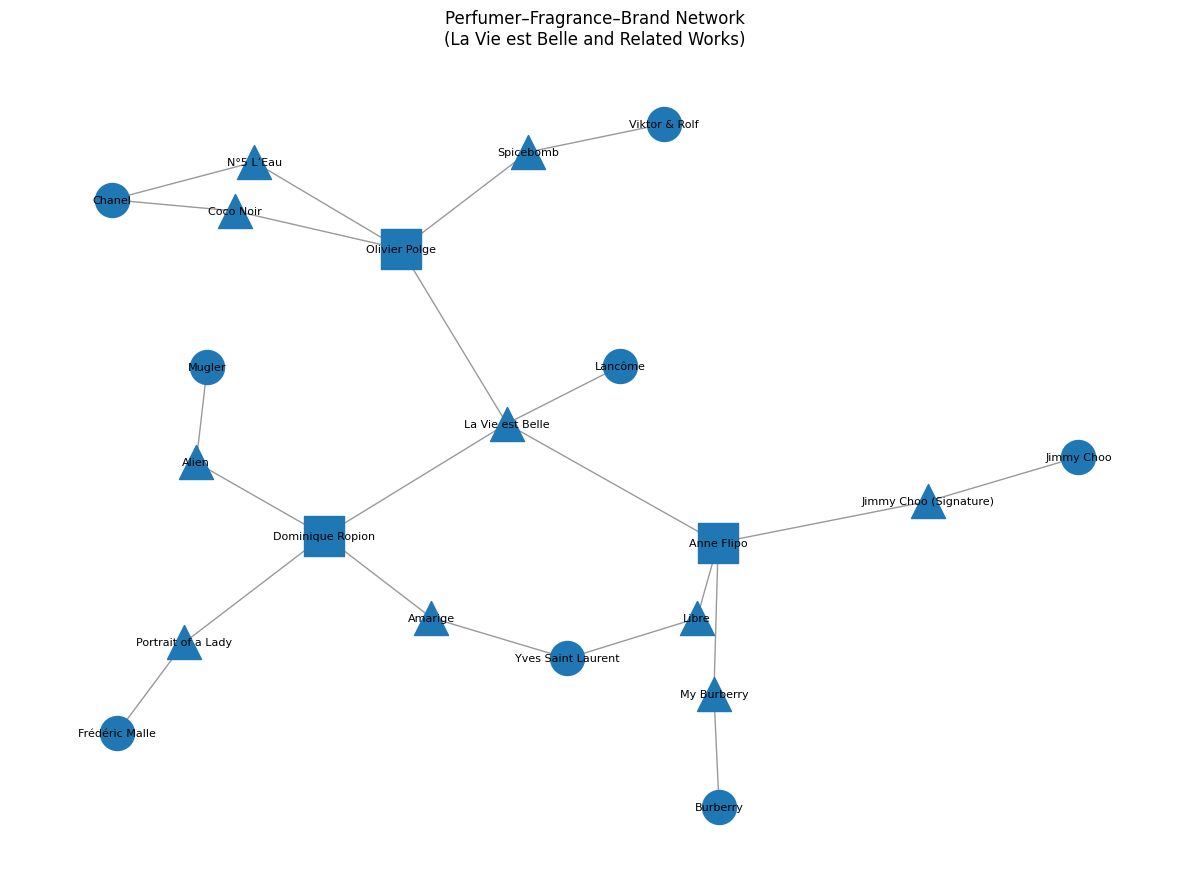

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# -----------------------------
# Define graph
# -----------------------------
G = nx.Graph()

# Perfumers
perfumers = [
    "Olivier Polge",
    "Dominique Ropion",
    "Anne Flipo",
]

# Brands / Houses
brands = [
    "Lancôme",
    "Chanel",
    "Mugler",
    "Frédéric Malle",
    "Yves Saint Laurent",
    "Burberry",
    "Viktor & Rolf",
    "Jimmy Choo",
]

# Fragrances
fragrances = [
    "La Vie est Belle",
    "N°5 L’Eau",
    "Coco Noir",
    "Spicebomb",
    "Alien",
    "Portrait of a Lady",
    "Amarige",
    "Libre",
    "My Burberry",
    "Jimmy Choo (Signature)",
]

# Add nodes with a type attribute for later styling
for p in perfumers:
    G.add_node(p, ntype="Perfumer")

for b in brands:
    G.add_node(b, ntype="Brand")

for f in fragrances:
    G.add_node(f, ntype="Fragrance")

# -----------------------------
# Add edges (relationships)
# -----------------------------
# La Vie est Belle trio
G.add_edge("Olivier Polge", "La Vie est Belle")
G.add_edge("Dominique Ropion", "La Vie est Belle")
G.add_edge("Anne Flipo", "La Vie est Belle")
G.add_edge("La Vie est Belle", "Lancôme")

# Olivier Polge
G.add_edge("Olivier Polge", "N°5 L’Eau")
G.add_edge("Olivier Polge", "Coco Noir")
G.add_edge("Olivier Polge", "Spicebomb")
G.add_edge("N°5 L’Eau", "Chanel")
G.add_edge("Coco Noir", "Chanel")
G.add_edge("Spicebomb", "Viktor & Rolf")

# Dominique Ropion
G.add_edge("Dominique Ropion", "Alien")
G.add_edge("Dominique Ropion", "Portrait of a Lady")
G.add_edge("Dominique Ropion", "Amarige")
G.add_edge("Alien", "Mugler")
G.add_edge("Portrait of a Lady", "Frédéric Malle")
G.add_edge("Amarige", "Yves Saint Laurent")  # historically Givenchy, but included here as an example node

# Anne Flipo
G.add_edge("Anne Flipo", "Libre")
G.add_edge("Anne Flipo", "My Burberry")
G.add_edge("Anne Flipo", "Jimmy Choo (Signature)")
G.add_edge("Libre", "Yves Saint Laurent")
G.add_edge("My Burberry", "Burberry")
G.add_edge("Jimmy Choo (Signature)", "Jimmy Choo")

# -----------------------------
# Layout
# -----------------------------
# Use spring layout for a “network” feel
pos = nx.spring_layout(G, k=0.7, iterations=100)

# Split nodes by type for styling
perfumer_nodes = [n for n, d in G.nodes(data=True) if d["ntype"] == "Perfumer"]
brand_nodes = [n for n, d in G.nodes(data=True) if d["ntype"] == "Brand"]
frag_nodes = [n for n, d in G.nodes(data=True) if d["ntype"] == "Fragrance"]

plt.figure(figsize=(12, 9))

# Draw edges first
nx.draw_networkx_edges(G, pos, alpha=0.4)

# Draw node groups (using default colors; no explicit color selection)
nx.draw_networkx_nodes(G, pos, nodelist=perfumer_nodes, node_shape="s", node_size=800)
nx.draw_networkx_nodes(G, pos, nodelist=brand_nodes, node_shape="o", node_size=600)
nx.draw_networkx_nodes(G, pos, nodelist=frag_nodes, node_shape="^", node_size=600)

# Labels
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Perfumer–Fragrance–Brand Network\n(La Vie est Belle and Related Works)")
plt.axis("off")
plt.tight_layout()

# Save high-res PNG
#plt.savefig("perfumer_network.png", dpi=300)

plt.show()